In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression

c:\Users\hosse\anaconda3\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.2)
  from scipy.stats import gaussian_kde


## Modeling Setup

### load datasets

In [3]:
file_names = ['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']

for name in file_names:
    globals()[name] = pd.read_csv(f'data/processed/{name}.csv')

In [4]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((16561, 16), (16561, 1), (4070, 16), (4070, 1), (100, 16), (100, 1))

### Define Evaluation Metrics

## Evaluation Metrics

We evaluate performance using MAE, RMSE, R², and the NASA Score.

- **MAE (Mean Absolute Error)**: Average prediction error in cycles. For instance, MAE = 12 indicates our prediction deviates by 12 cycles on average.

- **RMSE (Root Mean Squared Error)**: Penalizes larger errors more heavily than MAE.

- **R² (Coefficient of Determination)**: Explains the proportion of variance in RUL captured by the model. Higher values indicate better performance.

- **NASA Score**: Asymmetric scoring function used in the PHM challenge.

In RUL prediction, errors have unequal costs. Late predictions (overestimating life) are riskier than early ones. Thus, the C-MAPSS/PHM evaluation uses an asymmetric scoring function, penalizing late predictions more heavily than early ones.

The scoring function for C-MAPSS is defined as:

$$
S(d) =
\begin{cases}
e^{-d/13} - 1, & d < 0 \quad \text{(early prediction)} \\
e^{d/10} - 1, & d \ge 0 \quad \text{(late prediction)}
\end{cases}
$$

where $d = \hat{RUL} - RUL$.

In [5]:
def MAE(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

def RMSE(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

def R2(y_true, y_pred):
    return r2_score(y_true, y_pred)

def nasa_score(y_true, y_pred):
    error = y_pred - y_true

    score = np.where(
        error < 0,
        np.exp(-error / 13) - 1,
        np.exp(error / 10) - 1
    )

    return np.sum(score)

In [6]:
# make a table of all metrics for a model

def evaluate_model(y_true, y_pred, model_name):
    results = {
        "Model": model_name,
        "MAE": MAE(y_true, y_pred),
        "RMSE": RMSE(y_true, y_pred),
        "R2": R2(y_true, y_pred),
        "NASA Score": nasa_score(y_true, y_pred)
    }
    
    return pd.DataFrame([results]).round(2)

## Baseline Model

### Linear Regression

In [7]:
reg = LinearRegression() 
reg = reg.fit(X_train, y_train)
y_val_pred = reg.predict(X_val)

evaluate_model(y_val, y_val_pred, model_name ="regression")

,Model,MAE,RMSE,R2,NASA Score
0,regression,30.13,38.15,0.66,2218919.66


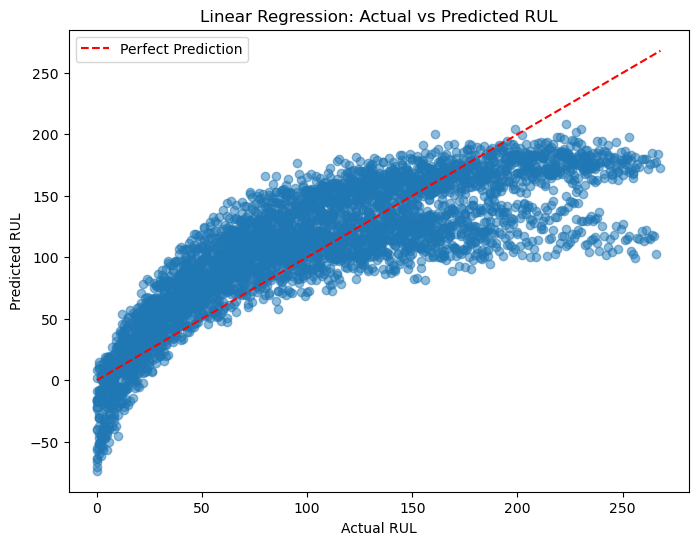

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(y_val, y_val_pred, alpha=0.5)

plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--",
    color='red',
    label='Perfect Prediction'
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Linear Regression: Actual vs Predicted RUL")
plt.legend()
plt.show()


Observation:
The model works better when the actual RUL is low, and many predictions are close to the perfect prediction line. However, when the actual RUL becomes higher, the model starts to underestimate it. Most predictions stay around 150–190 cycles even when the actual RUL is much higher. This shows that Linear Regression cannot fully capture the more complex relationship between the features and RUL.